First we must import libraries and methods that we will use in this notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ml_from_scratch.supervised.single_neuron import SingleNeuron, sigmoid

Now we will load the data that we need to test our model and split it into training and testing data. We also will scale this data as the different features are not uniformly scaled.

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Now we will train our model on the training data using the single_neuron class implemented above

In [4]:
model = SingleNeuron(activation_function=sigmoid)
model.train(X_train, y_train, alpha=0.01, epochs=1000)

Now that the model is trained, we will ensure that the cost curve decreased overtime so we know the model was actually learning

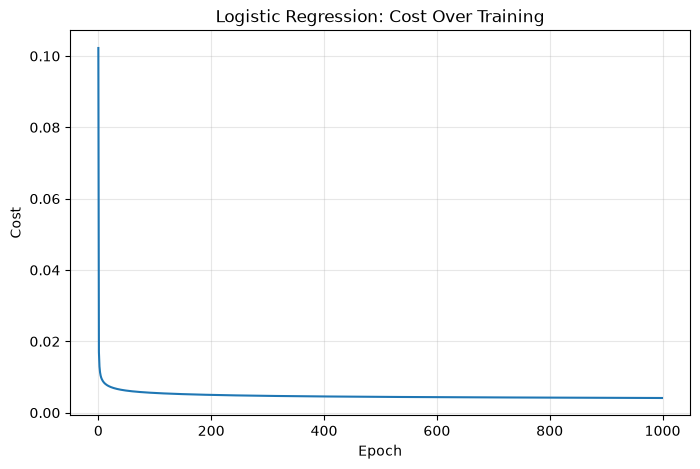

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(model.errors_)
plt.xlabel('Epoch'); plt.ylabel('Cost')
plt.title('Logistic Regression: Cost Over Training')
plt.grid(True, alpha=0.3)
plt.show()

As you can see, the cost raoidly decreased after a very small number of epochs. This is likely because there are strong correlations in this set and we have a large number of features which makes it much easier for the sigmoid function to separate our data. Now we will apply this model to the test data to see how accurate it is. Note that the current values are not classes (Malignant or benign) but rather probability values from 0 to 1. We will convert them to classes by rounding them to the nearest integer.

In [6]:
raw = np.array([model.predict(x) for x in X_test])  
preds = (raw >= 0.5).astype(int)                     

accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9737


That is a very high accuracy, a good sign that our model is pretty effective.